# Assignment 4: Regularization
Kaitlin Luu

### Q1

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
As a model's parameters increase, the model's output becomes very sensitive to even small changes in the input. This causes it to overfit to capture random noise. By adding a penalty to mean squared error that grows with the model's parameters this forces the the parameters to remain a reasonable size, which smoothens out the model.

2. How does regularization provide a way of exploring the bias-variance trade-off?
Regularization provides a balance between bias and variance so that the model does not overfit nor underfit. High variance results in an overly-sensitive model that bends to fit the noise. On the other hand, bias results in an over-simplified model that may ignore crucial features in the data. 

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
Ridge regression shrinks all of the coefficients towards zero, but doesn't actually set any of them to zero. This results in having the same number of coefficients as you had variables. On the other hand, LASSO regression shrinks some coefficients to zero to get rid of variables that are not needed. This results in having less coefficients than you had variables. 

4. How do we typically scale variables for use in regularized regression? Why?
We typically scale variables by using the z-score formula (subtract the mean from each score and divide by standard deviation) to standardize the coefficients. We do this so that all the coefficients are in the same range, which allows us to do computations with them. 

5. How is the penalty a typically selected?
The penalty a (alpha) is typically selected using hyperparameter tuning. This involves testing several different values and seeing which one makes the model perform best on unseen data (the validation folds). The most common way to pick the penalty is k-fold cross validation, which splits the training data into k parts, trains the model k times on a different subset each time, and repeats the process for many different a values. The performance on each is evaluating with MSE and the a value wit the lowest error is selected as the penalty

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
When conducting cross validation, you do not include the penalty term because models with larger penalties will look like they perform worse even if they perform better in reality. Therefore, we just use MSE since it is the only thing need to evaluate the model's performance. 

### Q2

In [1]:
# 1

import pandas as pd
import numpy as np

cars = pd.read_csv('data/cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [2]:
current_year = 2026
cars['Age'] = current_year - cars['Make_Year']
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [3]:
from sklearn.preprocessing import PolynomialFeatures

X = cars[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

print(X_poly_df.head())

   Mileage_Run   Age  Mileage_Run^2  Mileage_Run Age  Age^2  Mileage_Run^3  \
0      44611.0   9.0   1.990141e+09         401499.0   81.0   8.878219e+13   
1      20305.0  10.0   4.122930e+08         203050.0  100.0   8.371610e+12   
2      29540.0   7.0   8.726116e+08         206780.0   49.0   2.577695e+13   
3      35680.0   9.0   1.273062e+09         321120.0   81.0   4.542287e+13   
4      25126.0   9.0   6.313159e+08         226134.0   81.0   1.586244e+13   

   Mileage_Run^2 Age  Mileage_Run Age^2   Age^3  
0       1.791127e+10          3613491.0   729.0  
1       4.122930e+09          2030500.0  1000.0  
2       6.108281e+09          1447460.0   343.0  
3       1.145756e+10          2890080.0   729.0  
4       5.681843e+09          2035206.0   729.0  


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
print(X_scaled_df.head())

   Mileage_Run       Age  Mileage_Run^2  Mileage_Run Age     Age^2  \
0     0.124692 -0.013092      -0.137673        -0.045119 -0.157264   
1    -0.872334  0.341858      -0.791316        -0.677034  0.190081   
2    -0.493517 -0.722993      -0.600623        -0.665157 -0.742267   
3    -0.241655 -0.013092      -0.434732        -0.301067 -0.157264   
4    -0.674578 -0.013092      -0.700583        -0.603528 -0.157264   

   Mileage_Run^3  Mileage_Run^2 Age  Mileage_Run Age^2     Age^3  
0      -0.294615          -0.230767          -0.195586 -0.270422  
1      -0.661216          -0.718186          -0.564890  0.044089  
2      -0.581863          -0.648004          -0.700911 -0.718398  
3      -0.492295          -0.458906          -0.364354 -0.270422  
4      -0.627064          -0.663078          -0.563792 -0.270422  


In [5]:
# 2

from sklearn.linear_model import LinearRegression

y = cars['Price']

model = LinearRegression()
model.fit(X_scaled_df, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
coefs = pd.Series(model.coef_, index=X_scaled_df.columns)
interaction_coef = coefs['Mileage_Run Age']
print(interaction_coef)

-1671212.356391884


The sign is negative, meaning that as both mileage and age increase, the car's price drops more dramatically than it would for either variable alone. 

In [7]:
# 3

from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled_df, y)

print('Best alpha:', lasso_cv.alpha_)

Best alpha: 88.58667904100822


In [8]:
lasso_coefs = pd.Series(lasso_cv.coef_, index=X_scaled_df.columns)
print(lasso_coefs)

Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Age^2                0.000000e+00
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64


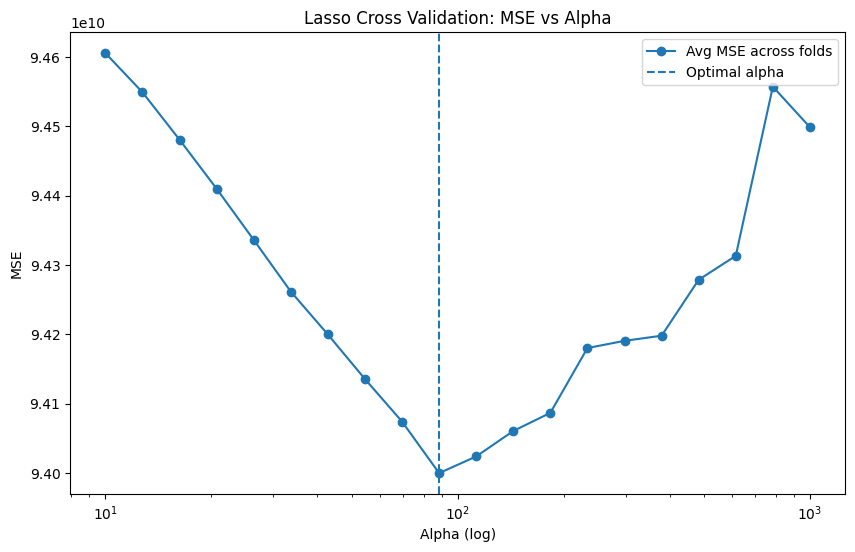

In [9]:
# 4

import matplotlib.pyplot as plt

avg_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(lasso_cv.alphas_, avg_mse, label='Avg MSE across folds', marker='o')

plt.axvline(lasso_cv.alpha_, linestyle='--', label='Optimal alpha')

plt.xscale('log')
plt.xlabel('Alpha (log)')
plt.ylabel('MSE')
plt.title('Lasso Cross Validation: MSE vs Alpha')
plt.legend()

plt.show()

C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.874e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or c

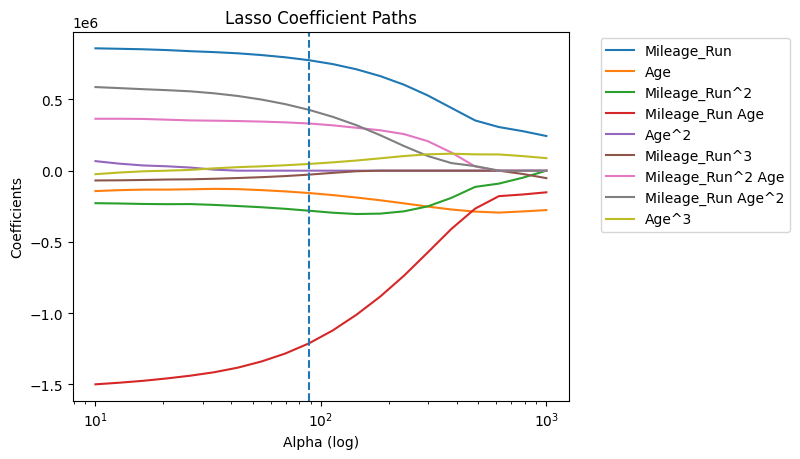

In [10]:
# 5

from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_scaled, y, alphas=alphas)

plt.plot(alphas_path, coefs_path.T)
plt.xscale('log')
plt.xlabel('Alpha (log)')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficient Paths')
plt.legend(X_scaled_df.columns, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axvline(lasso_cv.alpha_, linestyle='--', label='best alpha')
plt.show()

6.
It appears that all of the features except for Mileage_Run^3 are selected since Mileage_Run^3 is the only feature that touches the 0 axis at the best alpha. Therefore, 1/9 features are set equal to 0. 

In [11]:
# 7

comparison = pd.DataFrame({
    'Standard_Linear': coefs,
    'Lasso_Regularized': lasso_coefs
})

comparison['Magnitude_Change'] = comparison['Lasso_Regularized'].abs() - comparison['Standard_Linear'].abs()

comparison['Sign_Flip'] = np.sign(comparison['Standard_Linear']) != np.sign(comparison['Lasso_Regularized'])

comparison.loc[comparison['Lasso_Regularized'] == 0, 'Sign_Flip'] = False

print(comparison)

                   Standard_Linear  Lasso_Regularized  Magnitude_Change  \
Mileage_Run           9.117748e+05       7.790762e+05    -132698.635572   
Age                  -2.481722e+05      -1.339534e+05    -114218.754278   
Mileage_Run^2        -2.072926e+05      -2.015634e+05      -5729.219801   
Mileage_Run Age      -1.671212e+06      -1.322419e+06    -348793.510111   
Age^2                 3.505507e+05       0.000000e+00    -350550.719877   
Mileage_Run^3        -6.514490e+04      -4.240952e+04     -22735.380191   
Mileage_Run^2 Age     3.388195e+05       2.715062e+05     -67313.266303   
Mileage_Run Age^2     7.167816e+05       5.415432e+05    -175238.392224   
Age^3                -2.100379e+05       1.374220e+04    -196295.684456   

                   Sign_Flip  
Mileage_Run            False  
Age                    False  
Mileage_Run^2          False  
Mileage_Run Age        False  
Age^2                  False  
Mileage_Run^3          False  
Mileage_Run^2 Age      False  
M

Yes, most of the coefficients  increase in magnitude from linear regression to LASSO. These are Age, Mileage_Run^2, Mileage_Run Age, Age^2, Mileage_Run^3, and Age^3. Age^3 is the only coefficient that changes sign (negative to positive). 

### Q3

In [12]:
# 1

heart = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
heart.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [13]:
X = heart[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

In [14]:
X_cat = heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly_int = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat_interacted = poly_int.fit_transform(X_cat)

X_final = np.concatenate([X_poly_scaled, X_cat_interacted], axis=1)

poly_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
cat_names = poly_int.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

final_df = pd.DataFrame(X_final, columns=list(poly_names) + list(cat_names))
print(final_df)

          age  ejection_fraction  serum_creatinine     age^2  \
0    1.192945          -1.530560          0.490057  1.177180   
1   -0.491279          -0.007077         -0.284552 -0.539187   
2    0.350833          -1.530560         -0.090900  0.252982   
3   -0.912335          -1.530560          0.490057 -0.885761   
4    0.350833          -1.530560          1.264666  0.252982   
..        ...                ...               ...       ...   
294  0.098199          -0.007077         -0.284552  0.001468   
295 -0.491279          -0.007077         -0.187726 -0.539187   
296 -1.333392           1.854958         -0.575031 -1.199328   
297 -1.333392          -0.007077          0.005926 -1.199328   
298 -0.912335           0.585389          0.199578 -0.885761   

     age ejection_fraction  age serum_creatinine  ejection_fraction^2  \
0                -0.939354              0.777328            -1.197120   
1                -0.267742             -0.365953            -0.146835   
2           

In [15]:
# 2

X = final_df
y = heart['DEATH_EVENT']

model = LinearRegression()
model.fit(X, y)

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                                   Feature  Coefficient
6                      ejection_fraction^2     3.430976
7       ejection_fraction serum_creatinine     2.673394
9                                    age^3     1.993135
5                     age serum_creatinine     1.841563
0                                      age     1.539156
14                  age serum_creatinine^2     1.284099
17    ejection_fraction serum_creatinine^2     1.179475
10                 age^2 ejection_fraction     0.908026
27                        diabetes smoking     0.156078
26            diabetes high_blood_pressure     0.132443
28             high_blood_pressure smoking     0.101455
18                      serum_creatinine^3     0.072156
25                         anaemia smoking     0.064908
23                        anaemia diabetes     0.026159
19                                 anaemia     0.008093
21                     high_blood_pressure    -0.007934
24             anaemia high_blood_pressure    -0

Based on the coefficients, there are some sign patterns that appear counterintuitive. For instance, age^2 has a negative coefficient, whereas age and age^3 have positive ones, which indicates that likelihood of death decreases as you age. Additionally, smoking has a positive coefficient, which is counterintuitive based on what we know about smoking's impact on health. These counterintuitive sign patterns exist because of multicollinearity, which is caused by the polynomial expansion. However, the inclusion of higher-order powers or interactions might resolve these contradictions because it would allow the model to capture non-linear aspects and understand risk better than a regular linear model would.

In [16]:
# 3

alphas = np.logspace(-5, 5, 30)

lasso_model = LassoCV(alphas=alphas, cv=20, random_state=42)
lasso_model.fit(X_final, y)

poly_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
cat_names = poly_int.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
all_features = list(poly_names) + list(cat_names)

coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': lasso_model.coef_})

print(coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False))
print('Optimal Alpha:', lasso_model.alpha_)

                                 Feature  Coefficient
15                   ejection_fraction^3     0.204822
9                                  age^3     0.117992
2                       serum_creatinine     0.116875
26          diabetes high_blood_pressure     0.053968
16  ejection_fraction^2 serum_creatinine     0.032801
28           high_blood_pressure smoking     0.017805
19                               anaemia     0.014178
21                   high_blood_pressure     0.013608
27                      diabetes smoking     0.003466
20                              diabetes     0.000607
18                    serum_creatinine^3    -0.043266
1                      ejection_fraction    -0.329656
Optimal Alpha: 0.005736152510448681


C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.070e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.894e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or c

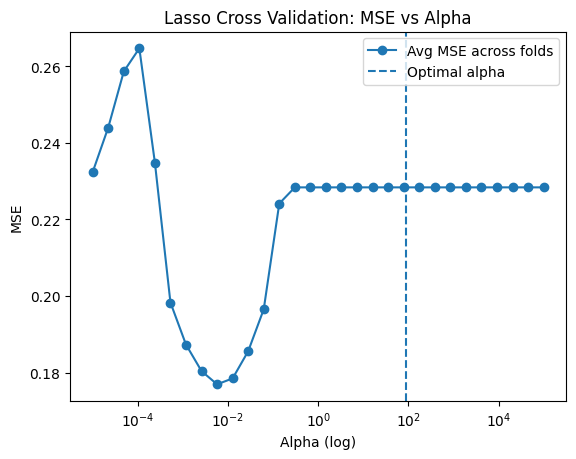

In [17]:
# 4

avg_mse = np.mean(lasso_model.mse_path_, axis=1)

plt.plot(lasso_model.alphas_, avg_mse, label='Avg MSE across folds', marker='o')

plt.axvline(lasso_cv.alpha_, linestyle='--', label='Optimal alpha')

plt.xscale('log')
plt.xlabel('Alpha (log)')
plt.ylabel('MSE')
plt.title('Lasso Cross Validation: MSE vs Alpha')
plt.legend()
plt.show()

C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.335e-01, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.280e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or c

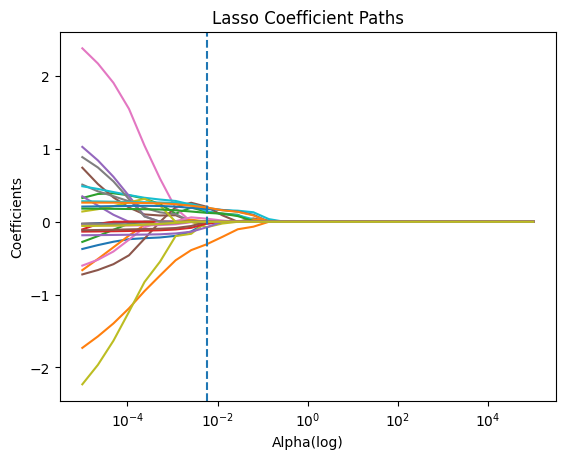

In [18]:
# 5

alphas_path, coefs, _ = lasso_path(X_final, y, alphas=np.logspace(-5, 5, 30))

for i in range(coefs.shape[0]):
    plt.plot(alphas_path, coefs[i, :])

plt.axvline(lasso_model.alpha_, linestyle='--', label='Optimal alpha')

plt.xscale('log')
plt.xlabel('Alpha(log)')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficient Paths')
plt.show()

In [19]:
# 6

total_features = len(lasso_model.coef_)
selected_features = np.sum(lasso_model.coef_ != 0)
zero_features = np.sum(lasso_model.coef_ == 0)
proportion_zero = zero_features / total_features

print('Selected features:', selected_features)
print('Proportion set to zero:', proportion_zero)

Selected features: 12
Proportion set to zero: 0.5862068965517241


There are 12 selected features. The ones with the highest coefficients are age^3 and serum_creatinine. The proportion of features set to zero is 0.586. None of the coefficients increase in magnitude from linear regression to LASSO. There are a lot of negative numbers in the linear regression, and there are vew few negative numbers among the regularized coefficients. I can see that serum_creatinine, diabetes, and high_blood_pressure changed signs from negative to positive when LASSO was applied. 

I think the LASSO model makes more sense, especially in a medical context, because it does not capture as much noise as a simple linear regression does. It also results in a good bias-variance trade off since it lowers variance by allowing for a small amount of bias. This way, the model is trained to perform better on unseen data (in this case, new patients).

### Q4

![page1](hw4q4a.jpg)
![page2](hw4q4b.jpg)